In [ ]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

In [ ]:
df = pd.read_csv("/content/gtsrb_dataset.csv")
speed_classes = [1, 2, 3, 4, 5,6, 7, 8, 9, 10, 11, 12]

In [ ]:
new_labels = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4,
    6: 5,
    7: 6,
    8: 7,
    9: 8,
    10: 9,
    11: 10,
    12: 11
}

df_speed = pd.DataFrame(columns=df.columns)

for index, row in df.iterrows():
    original_label = row["label"]
    if original_label in speed_classes:


        new_row = row.copy()

        new_label = new_labels[original_label]
        new_row["label"] = new_label

        df_speed = pd.concat([df_speed, pd.DataFrame([new_row])], ignore_index=True)
print(df_speed)

                          image_path label
0       ./gtsrb_images/1/img_541.png     0
1      ./gtsrb_images/1/img_1452.png     0
2       ./gtsrb_images/1/img_428.png     0
3       ./gtsrb_images/1/img_538.png     0
4       ./gtsrb_images/1/img_626.png     0
...                              ...   ...
13405  ./gtsrb_images/9/img_9416.png     8
13406  ./gtsrb_images/9/img_9445.png     8
13407  ./gtsrb_images/9/img_9046.png     8
13408  ./gtsrb_images/9/img_9094.png     8
13409  ./gtsrb_images/9/img_8982.png     8

[13410 rows x 2 columns]


Distribuția etichetelor:
Etichetă 0: 1500 exemple
Etichetă 1: 1500 exemple
Etichetă 2: 960 exemple
Etichetă 3: 1320 exemple
Etichetă 4: 1260 exemple
Etichetă 5: 300 exemple
Etichetă 6: 960 exemple
Etichetă 7: 960 exemple
Etichetă 8: 990 exemple
Etichetă 9: 1350 exemple
Etichetă 10: 900 exemple
Etichetă 11: 1410 exemple


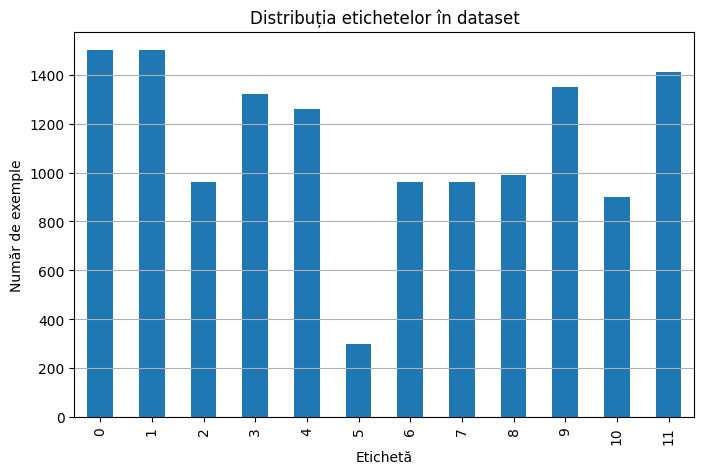

In [ ]:
counts = df_speed["label"].value_counts().sort_index()

# Afișăm valorile în consolă
print("Distribuția etichetelor:")
for label, count in counts.items():
    print(f"Etichetă {label}: {count} exemple")

# Afișăm graficul
plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Distribuția etichetelor în dataset")
plt.xlabel("Etichetă")
plt.ylabel("Număr de exemple")
plt.grid(axis='y')
plt.show()

In [ ]:
balanced_df = []
max_per_class = 1000
for label,count in counts.items():
    df_label = df_speed[df_speed['label'] == label]
    if len(df_label) > max_per_class:
        df_sample = df_label.sample(n=max_per_class, random_state=10)
        balanced_df.append(df_sample)
    else:
        balanced_df.append(df_label)

df_speed = pd.concat(balanced_df).reset_index(drop=True)

Distribuția etichetelor:
Etichetă 0: 1000 exemple
Etichetă 1: 1000 exemple
Etichetă 2: 960 exemple
Etichetă 3: 1000 exemple
Etichetă 4: 1000 exemple
Etichetă 5: 300 exemple
Etichetă 6: 960 exemple
Etichetă 7: 960 exemple
Etichetă 8: 990 exemple
Etichetă 9: 1000 exemple
Etichetă 10: 900 exemple
Etichetă 11: 1000 exemple


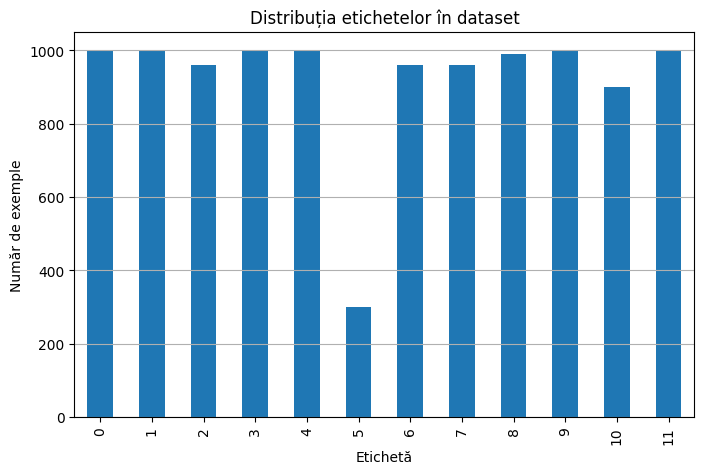

In [ ]:
counts = df_speed["label"].value_counts().sort_index()

# Afișăm valorile în consolă
print("Distribuția etichetelor:")
for label, count in counts.items():
    print(f"Etichetă {label}: {count} exemple")

# Afișăm graficul
plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Distribuția etichetelor în dataset")
plt.xlabel("Etichetă")
plt.ylabel("Număr de exemple")
plt.grid(axis='y')
plt.show()

In [ ]:
df_shuffled = df_speed.sample(frac=1, random_state=42).reset_index(drop=True)
train_test_ratio = 0.8
train_size = (int)(len(df_shuffled) *0.8)
test_size = len(df_shuffled) - train_size
df_train    = df_shuffled.iloc[:train_size].reset_index(drop=True)
df_test     = df_shuffled.iloc[train_size:].reset_index(drop=True)

print("Train:", len(df_train), "– Test:", len(df_test))

Train: 8856 – Test: 2214


In [ ]:
image_size = (50,50)
def preprocess_image(img, size=image_size):
    img = img.resize(size)
    img = img.convert("L")
    arr = np.array(img, dtype=np.float32)
    arr = arr.flatten()
    arr /= 255
    return arr

In [ ]:
def one_hot(Y, num_classes):
    Y = Y.astype(int)
    m = Y.shape[0]
    Y_oh = np.zeros((num_classes, m), dtype=np.int32)
    Y_oh[Y, np.arange(m)] = 1
    return Y_oh

In [ ]:
total_pixels = image_size[0]*image_size[1]
num_classes = 12
number_images = len(df_train)

X_train = np.zeros((number_images, total_pixels), dtype=np.float32)
for i, path in enumerate(df_train["image_path"]):
    X_train[i,:] = preprocess_image(Image.open(path))
print(X_train.shape)
X_train = X_train.T
print(X_train.shape)
Y_train = one_hot(np.array(df_train["label"].values.astype("float32")), num_classes)

NameError: name 'image_path' is not defined

In [ ]:
number_images = len(df_test)
m_test = len(df_test)
X_test = np.zeros((total_pixels, number_images), dtype=np.float32)
for i, path in enumerate(df_test["path"]):
    X_test[:, i] = preprocess_image(Image.open(path))
Y_test = one_hot(np.array(df_test["label"].values.astype("float32")), num_classes)
print(X_test.shape)

KeyError: 'path'

In [ ]:
# Transpose inputs back for TensorFlow (samples, features)
X_train_tf = X_train.T
X_test_tf = X_test.T

# Transpose labels to match TensorFlow expectations (samples, classes)
Y_train_tf = Y_train.T
Y_test_tf = Y_test.T

# Build the neural network model
model = Sequential([
    Input(shape=(X_train_tf.shape[1],)),          # Input layer
    Dense(20, activation='relu'),                 # Hidden layer 1
    Dense(20, activation='relu'),                 # Hidden layer 2
    Dense(num_classes, activation='softmax')      # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train_tf, Y_train_tf, epochs=15, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test_tf, Y_test_tf)
print(f"\nTest accuracy: {test_acc:.4f}")

NameError: name 'Y_train' is not defined